In [3]:
pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/549.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 707.5 kB/s  0:00:00

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- -----------------

In [1]:
import pandas as pd                                     #For Handling datasets as DataFrame
import numpy as np                                      #For numerical operations
from sklearn.preprocessing import LabelEncoder,StandardScaler          #Encode categorical values & scale numbers
from sklearn.model_selection import train_test_split                   #Split data into train/test
from imblearn.over_sampling import SMOTE                               #Handle imbalanced dataset
from sqlalchemy import create_engine                                  #Connect to database

In [2]:
#Read Dataset from Db
#Needed to read tables directly into Pandas
df=pd.read_csv("FAKE-TRANSACTION-DATASET.csv")                         #converts it into Dataframe
df.head()   #show the 5 rows of the Dataframe by default

,txn_id,amount,ip_address,is_fraud,location,txn_type,account,device,time_stamp,oldBalance,newBalance,userId,deviceId
0,TXN1,100,10.0.0.1,True,NY,DEBIT,ACC1,ANDROID,1/28/2025 10:00,500,400,U1,D1
1,TXN2,120,10.0.0.2,True,NY,DEBIT,ACC1,ANDROID,1/28/2025 10:05,400,280,U1,D1
2,TXN3,80,10.0.0.3,True,NY,DEBIT,ACC1,ANDROID,1/28/2025 10:10,280,200,U1,D1
3,TXN4,60,10.0.0.4,True,NY,DEBIT,ACC1,ANDROID,1/28/2025 10:15,200,140,U1,D1
4,TXN5,50,10.0.0.5,True,NY,DEBIT,ACC1,ANDROID,1/28/2025 10:20,140,90,U1,D1


In [3]:
#Remove Duplicates
df=df.drop_duplicates()
#this Removes repeated rows to avoid bias or errors in ML training

In [4]:
                                                        #Handle Missing Values
#fill missing categorical values with 'unknown'
categorical_cols=['userId','deviceId','location','txn_type','txn_id','ip_address']
for col in categorical_cols:
    df[col]=df[col].fillna("unknown")
#.fillna("unknown") → replaces all missing values (NaN) in that column with the string "unknown".
#df[col] = ... → assigns the result back to the same column.


#fill missing numeric values with median
numeric_cols=['amount','oldBalance','newBalance']
for col in numeric_cols:
    df[col]=df[col].fillna(df[col].median())


In [5]:
#convert Timestamp to features
df['timestamp']=pd.to_datetime(df['time_stamp'])   #Convert String to datatime

#extract useful features
df['hour']=df['timestamp'].dt.hour
df['day']=df['timestamp'].dt.day
df['month']=df['timestamp'].dt.month
df['weekday']=df['timestamp'].dt.weekday
#Ml models can use hour,day,weekday as fraud indicators
#transactions at odd hours are often suspacious

print(df['timestamp'])

0    2025-01-28 10:00:00
1    2025-01-28 10:05:00
2    2025-01-28 10:10:00
3    2025-01-28 10:15:00
4    2025-01-28 10:20:00
             ...        
95   2025-01-28 10:45:00
96   2025-01-28 10:50:00
97   2025-01-28 10:55:00
98   2025-01-28 11:00:00
99   2025-01-28 11:05:00
Name: timestamp, Length: 100, dtype: datetime64[ns]


In [6]:
#Encode Categorical Columns
le=LabelEncoder()
df['txn_type']=le.fit_transform(df['txn_type'])
df['location']=le.fit_transform(df['location'])
df['ip_address ']=le.fit_transform(df['ip_address'])
df['is_fraud']=le.fit_transform(df['is_fraud'])
df['amount']=le.fit_transform(df['amount'])
df['oldBalance']=le.fit_transform(df['oldBalance'])
df['userId']=le.fit_transform(df['userId'])
df['deviceId']=le.fit_transform(df['deviceId'])

#Converts string labels into numbers
#Required for ml models they can't handle text


In [7]:
df['is_fraud']

0     1
1     1
2     1
3     1
4     1
     ..
95    1
96    1
97    1
98    1
99    1
Name: is_fraud, Length: 100, dtype: int64

In [8]:
import json

In [9]:
#Feature Engineering
#Amount ratio (how big compared to old balance)
#print(df['account'].apply(type))
#df['oldBalance']=df['account'].apply(lambda x: json.loads(x).get('accountBalance', 0) if isinstance(x,str) else 0) 
#df['newBalance']=df['oldBalance']+df['amount']
#print(df['newBalance'])
#df['amount_ratio'] = df['amount']/(df['account']
#.apply(lambda x: json.loads(x).get('accountBalance', 0) if isinstance(x,str) else 0) 
                                  #+ 1)  # +1 to avoid division by zero
df['amount_ratio']=df['amount']/(df['oldBalance']+1)
df['amount_ratio'] 

0     0.533333
1     0.720000
2     0.631579
3     0.533333
4     0.545455
        ...   
95    0.666667
96    0.900000
97    1.333333
98    7.000000
99    0.300000
Name: amount_ratio, Length: 100, dtype: float64

In [10]:
#Fearure Engineering
#Flag new device meaning counting(flag) how many time user has used different devices
#New devices often trigger fraud checks
#df['userId']=df['device'].apply(lambda x:json.loads(x).get('userId',0) if isinstance(x,str) else 0)
#df['deviceId']=df['device'].apply(lambda x:json.loads(x).get('deviceId',0) if isinstance(x,str) else 0)
#df['new_device']=df.groupby('userId')['deviceId'].transform('nunique')
df['new_device']=df.groupby('userId')['deviceId'].transform(lambda x: x != x.mode()[0]).astype(int)   
#False → most-used device
#True → different (new) device
print(df['new_device'])

0     0
1     0
2     0
3     0
4     0
     ..
95    0
96    1
97    0
98    1
99    0
Name: new_device, Length: 100, dtype: int64


In [11]:
#Feature Engineering
#Transaction count in last hour (rolling)
#High frequency can indicate susupicious behavior
df=df.sort_values(by=['userId','timestamp']).reset_index(drop=True)  # optional but safest  
df['txn_count_hr'] = (
    df.groupby('userId')
      .rolling('1H', on='timestamp')['timestamp']  # select column
      .count()                                      # returns a Series
      .values            # align index
)
print(df['txn_count_hr'])



0      1.0
1      2.0
2      3.0
3      4.0
4      5.0
      ... 
95     6.0
96     7.0
97     8.0
98     9.0
99    10.0
Name: txn_count_hr, Length: 100, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_12796\761597287.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .rolling('1H', on='timestamp')['timestamp']  # select column
C:\Users\Admin\AppData\Local\Temp\ipykernel_12796\761597287.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.groupby('userId')


In [12]:
#print(df['is_fraud'])
#df.loc[df.sample(4, random_state=42).index, 'is_fraud'] = 1
#print(df['is_fraud'])
print(df['is_fraud'].value_counts())
print(df['is_fraud'])

is_fraud
1    52
0    48
Name: count, dtype: int64
0     1
1     1
2     1
3     1
4     1
     ..
95    1
96    1
97    1
98    1
99    1
Name: is_fraud, Length: 100, dtype: int64


In [13]:
df

,txn_id,amount,ip_address,is_fraud,location,txn_type,account,device,time_stamp,oldBalance,...,deviceId,timestamp,hour,day,month,weekday,ip_address,amount_ratio,new_device,txn_count_hr
0,TXN1,16,10.0.0.1,1,6,0,ACC1,ANDROID,1/28/2025 10:00,29,...,0,2025-01-28 10:00:00,10,28,1,1,0,0.533333,0,1.0
1,TXN2,18,10.0.0.2,1,6,0,ACC1,ANDROID,1/28/2025 10:05,24,...,0,2025-01-28 10:05:00,10,28,1,1,2,0.720000,0,2.0
2,TXN3,12,10.0.0.3,1,6,0,ACC1,ANDROID,1/28/2025 10:10,18,...,0,2025-01-28 10:10:00,10,28,1,1,3,0.631579,0,3.0
3,TXN4,8,10.0.0.4,1,6,0,ACC1,ANDROID,1/28/2025 10:15,14,...,0,2025-01-28 10:15:00,10,28,1,1,4,0.533333,0,4.0
4,TXN5,6,10.0.0.5,1,6,0,ACC1,ANDROID,1/28/2025 10:20,10,...,0,2025-01-28 10:20:00,10,28,1,1,5,0.545455,0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN91,6,10.0.8.6,1,7,0,ACC9,IOS,1/28/2025 9:25,14,...,2,2025-01-28 09:25:00,9,28,1,1,86,0.400000,0,6.0
96,TXN92,5,10.0.8.7,1,7,0,ACC9,IOS,1/28/2025 9:30,12,...,2,2025-01-28 09:30:00,9,28,1,1,87,0.384615,0,7.0
97,TXN93,4,10.0.8.8,1,7,0,ACC9,IOS,1/28/2025 9:35,7,...,2,2025-01-28 09:35:00,9,28,1,1,88,0.500000,0,8.0
98,TXN94,3,10.0.8.9,1,7,0,ACC9,IOS,1/28/2025 9:40,5,...,2,2025-01-28 09:40:00,9,28,1,1,89,0.500000,0,9.0


In [14]:
#Separate Features and Labels
X=df[['amount_ratio','new_device','txn_count_hr']]  #features 
# randomly label 10 rows as fraud (only for testing)
Y=df['is_fraud']                            #Target Variable
#x->input features for ML
#y->labels(fraud or not)

In [15]:
#Train/Test Split
X_train,X_test,Y_train,Y_test =train_test_split(
    X,Y,test_size=0.30,random_state=42,stratify=Y
)
#Always use stratify=y if your target is categorical, especially imbalanced.
#For regression tasks (continuous target), stratify is not used.

In [16]:
# Find the number of minority samples in training set
#minority_count = Y_train.value_counts()[1]  # number of frauds in training set
# Set n_neighbors safely
#k = min(5, minority_count - 1)  # must be < minority_count
#sm=SMOTE(k_neighbors=k,random_state=42)
#sm=SMOTE(random_state=42)
#X_train_balanced,y_train_balanced = sm.fit_resample(X_train,Y_train)

In [17]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
#X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [20]:
rf_model=RandomForestClassifier(n_estimators=200,max_depth=5,min_samples_leaf=5,class_weight='balanced',random_state=42)
rf_model.fit(X_train_scaled,Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
rf_pred=rf_model.predict(X_test_scaled)
print(rf_pred)

[1 0 1 0 0 1 1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 0 0 1 1 1 0]


In [22]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [23]:
#print(classification_report(Y_test,Y))

In [31]:
print(classification_report(Y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.94      0.94      0.94        16

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [32]:
rf_accuracy =accuracy_score(Y_test,rf_pred)
print("Accuracy",rf_accuracy)

Accuracy 0.9333333333333333


In [27]:
print("Train ac:",rf_model.score(X_train,Y_train))
print("Test ac:",rf_model.score(X_test,Y_test))

Train ac: 0.5142857142857142
Test ac: 0.5333333333333333


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


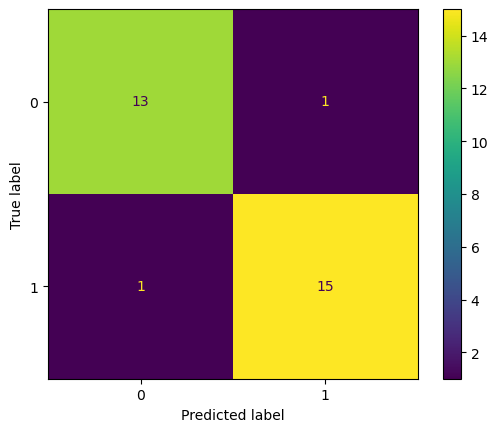

In [28]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test,rf_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [29]:
import pickle


In [30]:
with open("fraud_model.pkl","wb") as f:
    pickle.dump(rf_model,f)

In [42]:
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)